# VQCFD Gradient and Legacy Variance Analysis

The reusable loading and plotting functions live in `analysis.py`. The first section remains available for old variance-mode results; the new raw-gradient workflow is below.


In [29]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import analysis as an

an.configure_plots()
RESULTS_ROOT = an.RESULTS_ROOT
RESULTS_ROOT


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results')

## Discover legacy variance runs


In [2]:
variance_runs = an.discover_variance_runs()
an.print_variance_runs(variance_runs)


var_N2L1                 N=2   L=1   circuit=default    variance=0.31716497156749646 tries=4000
var_N2L2                 N=2   L=2   circuit=default    variance=0.2965365373132682 tries=4000
var_N2L4                 N=2   L=4   circuit=default    variance=0.279785533622202 tries=4000
var_N2L8                 N=2   L=8   circuit=default    variance=0.27073325456218755 tries=2000
var_N3L1                 N=3   L=1   circuit=default    variance=0.1442779785519855 tries=1000
var_N3L2                 N=3   L=2   circuit=default    variance=0.13890475032056604 tries=1000
var_N3L4                 N=3   L=4   circuit=default    variance=0.13305193118477224 tries=1000
var_N3L8                 N=3   L=8   circuit=default    variance=0.1279561159880521 tries=1000
var_N4L1                 N=4   L=1   circuit=default    variance=0.06925700385211589 tries=1000
var_N4L2                 N=4   L=2   circuit=default    variance=0.0664977257100345 tries=1000
var_N4L4                 N=4   L=4   circuit=d

## Select runs


In [3]:
# Add (dir_label, label) pairs for a controlled comparison, or leave empty to use all.
RUNS = [
    # ("var", "N2L1"),
    # ("var", "N3L1"),
]

# Each entry replaces its source runs with one variance computed from all raw gradient samples.
VARIANCE_COMBINATIONS = {
    "combined_N10L1": [("var", f"N10L1_{i}") for i in range(1, 5)],
    "combined_N10L2": [("var", f"N10L2_{i}") for i in range(1, 5)],
}

selected = [an.load_variance_run(d, label) for d, label in RUNS] if RUNS else variance_runs
selected = an.apply_variance_combinations(selected, VARIANCE_COMBINATIONS)
an.print_variance_runs(selected)
an.variance_table(selected)


var_N2L1                 N=2   L=1   circuit=default    variance=0.31716497156749646 tries=4000
var_N2L2                 N=2   L=2   circuit=default    variance=0.2965365373132682 tries=4000
var_N2L4                 N=2   L=4   circuit=default    variance=0.279785533622202 tries=4000
var_N2L8                 N=2   L=8   circuit=default    variance=0.27073325456218755 tries=2000
var_N3L1                 N=3   L=1   circuit=default    variance=0.1442779785519855 tries=1000
var_N3L2                 N=3   L=2   circuit=default    variance=0.13890475032056604 tries=1000
var_N3L4                 N=3   L=4   circuit=default    variance=0.13305193118477224 tries=1000
var_N3L8                 N=3   L=8   circuit=default    variance=0.1279561159880521 tries=1000
var_N4L1                 N=4   L=1   circuit=default    variance=0.06925700385211589 tries=1000
var_N4L2                 N=4   L=2   circuit=default    variance=0.0664977257100345 tries=1000
var_N4L4                 N=4   L=4   circuit=d

,full_label,n,l,circuit,variance,variance_tries,variance_num_samples,variance_runtime_s,gradient_mean,combined_from
0,var_N2L1,2,1,default,0.317165,4000,16000,5.563150e+03,NaN,NaN
1,var_N2L2,2,2,default,0.296537,4000,24000,5.948666e+03,NaN,NaN
2,var_N2L4,2,4,default,0.279786,4000,40000,1.535361e+04,NaN,NaN
3,var_N2L8,2,8,default,0.270733,2000,36000,2.388916e+04,NaN,NaN
4,var_N3L1,3,1,default,0.144278,1000,6000,6.930896e+02,NaN,NaN
5,var_N3L2,3,2,default,0.138905,1000,9000,1.399477e+03,NaN,NaN
6,var_N3L4,3,4,default,0.133052,1000,15000,9.662871e+03,NaN,NaN
7,var_N3L8,3,8,default,0.127956,1000,27000,3.035134e+04,NaN,NaN
8,var_N4L1,4,1,default,0.069257,1000,8000,3.053449e+03,NaN,NaN
9,var_N4L2,4,2,default,0.066498,1000,12000,2.358635e+03,NaN,NaN


## Variance plots


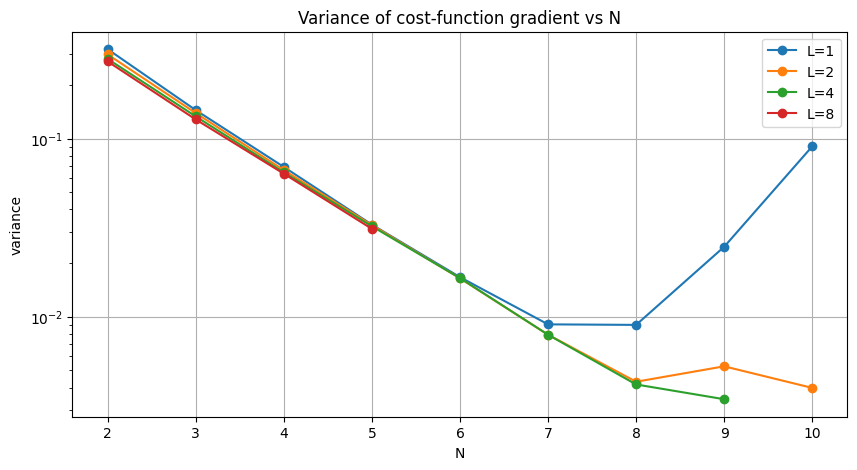

In [4]:
an.plot_variance_vs_n(selected, log_y=True);


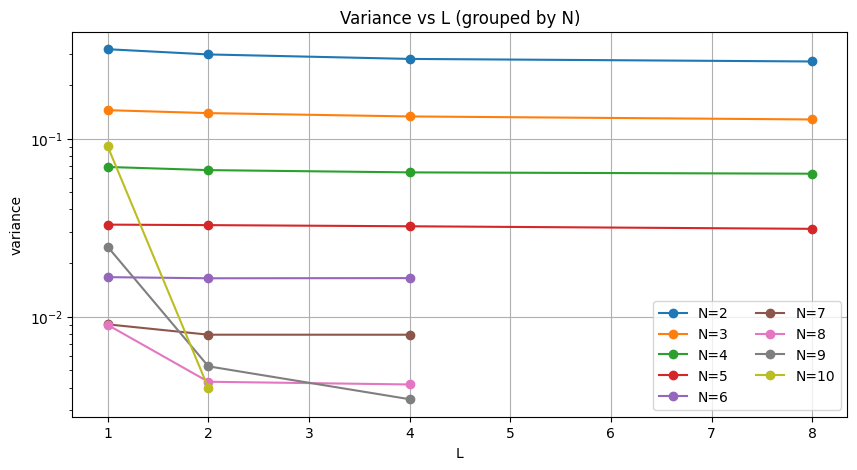

In [12]:
an.plot_variance_vs_l(selected, log_y=True);


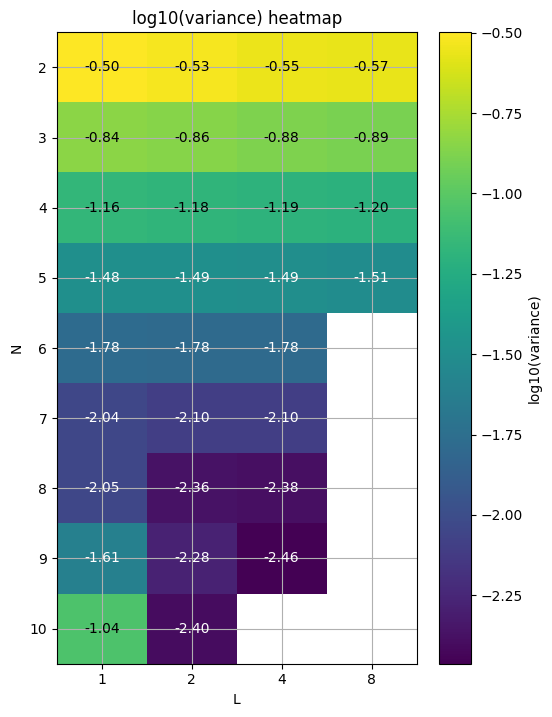

In [13]:
an.plot_variance_heatmap(selected);


## Inspect one run


In [5]:
if selected:
    selected[0]["values"]


## Discover and select gradient runs

Each run contains two aligned parameter-by-sweep matrices: `current_dt` and `fixed_diffusion`.


In [ ]:
gradient_runs = an.discover_gradient_runs()
an.print_gradient_runs(gradient_runs)


In [ ]:
# Add (dir_label, label) pairs for a controlled comparison, or leave empty to use all.
GRADIENT_RUNS = [
    # ("grad", "N2L1"),
    # ("grad", "N3L1"),
]

selected_gradient_runs = (
    [an.load_gradient_run(d, label) for d, label in GRADIENT_RUNS]
    if GRADIENT_RUNS else gradient_runs
)
an.print_gradient_runs(selected_gradient_runs)


## Statistics over all parameters

`mean_gradient` and `variance` pool every scalar gradient. `mean_gradient_norm` is the mean L2 norm of the complete gradient vector over random-parameter sweeps.


In [ ]:
gradient_run_stats = an.gradient_run_table(selected_gradient_runs)
gradient_run_stats


## Statistics for each parameter

For a single scalar parameter, its gradient norm is its absolute value, so `mean_gradient_norm` is the mean absolute gradient.


In [ ]:
gradient_parameter_stats = an.gradient_parameter_table(selected_gradient_runs)
gradient_parameter_stats


## Raw gradients

The nested dictionary below keeps the full matrices available for custom plots or statistics. Access one parameter with, for example, `gradient_matrices[run_label]["current_dt"][parameter_index]`.


In [ ]:
gradient_matrices = {
    row["full_label"]: an.load_gradient_matrices(row)
    for row in selected_gradient_runs
}
{run: {dataset: values.shape for dataset, values in matrices.items()}
 for run, matrices in gradient_matrices.items()}
